In [27]:
import pandas as pd
import numpy as np
car_data = pd.read_csv('car data.csv')
car_details = pd.read_csv('CAR DETAILS FROM CAR DEKHO.csv')
car_details_v3 = pd.read_csv('Car details v3.csv')
car_details_v4 = pd.read_csv('car details v4.csv')
pd.set_option('display.max_columns', None)

In [28]:
car_data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [29]:
# 1. 車の年齢（経過年数）を計算（2026年ベース）
# ※今年買ったばかりの車（経過年数0）で割り算してエラー（無限大）になるのを防ぐため、最低でも1年にします
car_data['Car_Age'] = 2026 - car_data['Year']
car_data['Car_Age'] = car_data['Car_Age'].clip(lower=1)

# 💡 ひらめき①：年間平均走行距離
# 総走行距離 ÷ 経過年数
car_data['Kms_Per_Year'] = car_data['Kms_Driven'] / car_data['Car_Age']

# 💡 ひらめき②：価格の差分（新車価格 - 販売価格）
car_data['Price_Diff'] = car_data['Present_Price'] - car_data['Selling_Price']

# 新しい列がちゃんと作れたか、右端を確認してみる
print(car_data[['Year', 'Car_Age', 'Kms_Driven', 'Kms_Per_Year', 'Present_Price', 'Selling_Price', 'Price_Diff']].head())

   Year  Car_Age  Kms_Driven  Kms_Per_Year  Present_Price  Selling_Price  \
0  2014       12       27000   2250.000000           5.59           3.35   
1  2013       13       43000   3307.692308           9.54           4.75   
2  2017        9        6900    766.666667           9.85           7.25   
3  2011       15        5200    346.666667           4.15           2.85   
4  2014       12       42450   3537.500000           6.87           4.60   

   Price_Diff  
0        2.24  
1        4.79  
2        2.60  
3        1.30  
4        2.27  


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import root_mean_squared_error # 予測が何万円ズレているか測る最新の関数

# 1. AIに渡すヒント（X）と、当てたい答え（y）に分ける
# ※名前（Car_Name）や、カンニングになる Price_Diff は外します
X = car_data.drop(columns=['Selling_Price', 'Car_Name', 'Price_Diff'])
y = car_data['Selling_Price']

# 2. 文字列の列（Fuel_Type, Seller_Type, Transmission）を、自動で0と1の数字に変換する
X = pd.get_dummies(X, drop_first=True)

# 3. 訓練データと検証データに分ける（今回はシンプルに 8:2 に分割）
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
# 【定型文】パイプラインを使って、全員に「桁を揃える前処理」を強制する
pipelines = {
    'LinearRegression（線形回帰）': Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LinearRegression())
    ]),
    'RandomForest（ランダムフォレスト）': Pipeline([
        ('scaler', StandardScaler()), # 実はランダムフォレストは桁がバラバラでも平気な強靭なAIです
        ('rf', RandomForestRegressor(random_state=42))
    ]),
    'SVR（サポートベクターマシン）': Pipeline([
        ('scaler', StandardScaler()), # 🌟 これでSVRの弱点が克服されます！
        ('svr', SVR())
    ])
}

print("--- ⚙️ パイプライン版・一括オーディション開始 ---")
results = {}
for name, pipe in pipelines.items():
    # データを渡すだけ。裏で自動的に「桁揃え ➡️ 学習」が流れます
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val)
    
    error = root_mean_squared_error(y_val, y_pred)
    print(f"{name} の平均誤差: {error:.4f}")
    results[name] = pipe
trained_models = results

--- ⚙️ パイプライン版・一括オーディション開始 ---
LinearRegression（線形回帰） の平均誤差: 1.8636
RandomForest（ランダムフォレスト） の平均誤差: 0.9527
SVR（サポートベクターマシン） の平均誤差: 2.3516


C:\Users\user\AppData\Local\Temp\ipykernel_4332\1384479344.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis')


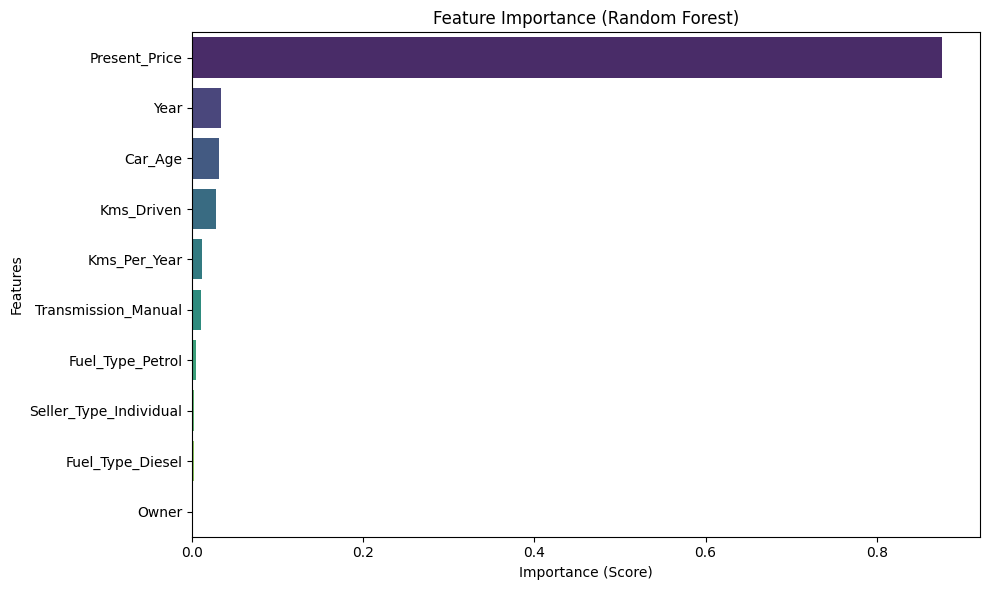

                  Feature  Importance
1           Present_Price    0.876905
0                    Year    0.033875
4                 Car_Age    0.031272
2              Kms_Driven    0.027341
5            Kms_Per_Year    0.010796
9     Transmission_Manual    0.010731
7        Fuel_Type_Petrol    0.003936
8  Seller_Type_Individual    0.002406
6        Fuel_Type_Diesel    0.002319
3                   Owner    0.000418


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. オーディション結果から、一番優秀だったランダムフォレストのパイプラインを取り出す
best_pipe = trained_models['RandomForest（ランダムフォレスト）']

# 2. パイプラインの中から、AI本体（rf）を取り出す
rf_model = best_pipe.named_steps['rf']

# 3. AIが計算した「各特徴量の重要度」をゲットする
importances = rf_model.feature_importances_
feature_names = X_train.columns

# 4. 見やすいようにデータフレーム（表）にまとめる
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False) # 重要度が高い順に並び替え

# 5. グラフの描画（日本語が文字化けしないようにシンプルに設定）
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance (Score)')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# 数値でも確認できるように上位を表示
print(df_importance)

C:\Users\user\AppData\Local\Temp\ipykernel_4332\581221993.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importance, palette='coolwarm') # 色味を少し変えました
C:\Users\user\AppData\Local\Temp\ipykernel_4332\581221993.py:23: UserWarning: Glyph 24433 (\N{CJK UNIFIED IDEOGRAPH-5F71}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_4332\581221993.py:23: UserWarning: Glyph 38911 (\N{CJK UNIFIED IDEOGRAPH-97FF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_4332\581221993.py:23: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24433 (\N{

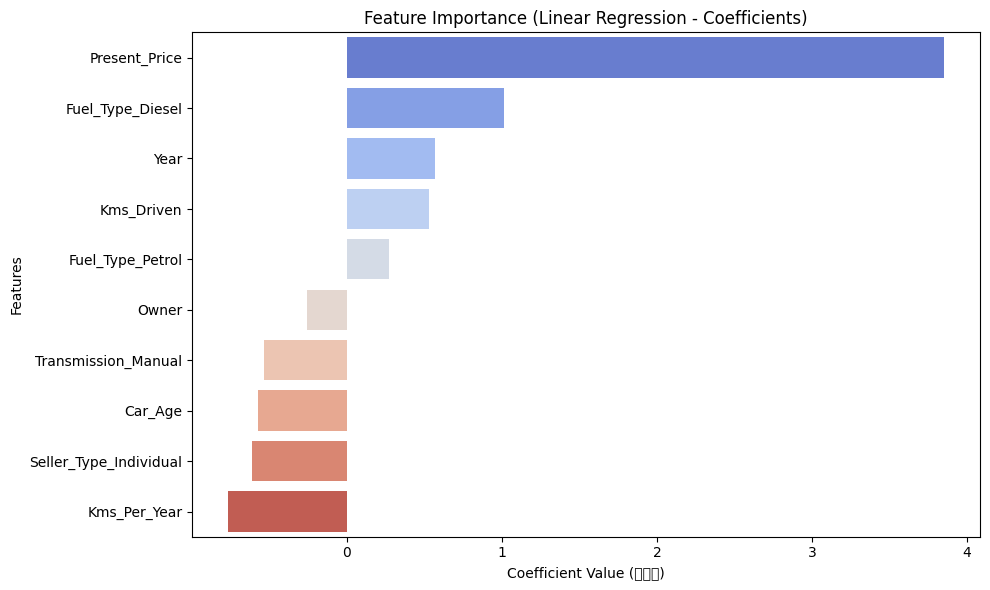

                  Feature  Importance
1           Present_Price    3.851919
6        Fuel_Type_Diesel    1.013513
0                    Year    0.569574
2              Kms_Driven    0.533748
7        Fuel_Type_Petrol    0.269660
3                   Owner   -0.253010
9     Transmission_Manual   -0.533944
4                 Car_Age   -0.569574
8  Seller_Type_Individual   -0.608097
5            Kms_Per_Year   -0.764741


In [39]:
# 1. 箱から「線形回帰」のパイプラインを取り出す（★ここを変更）
best_pipe = trained_models['LinearRegression（線形回帰）']

# 2. パイプラインの中から、AI本体（lr）を取り出す（★ここを lr に変更）
lr_model = best_pipe.named_steps['lr']

# 3. 🌟ここが仕組みの違い！線形回帰では「coef_（傾き・係数）」を使います
importances = lr_model.coef_  # ★ feature_importances_ ではなく coef_ になります
feature_names = X_train.columns

# 4. 見やすいようにデータフレームにまとめる
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 5. グラフの描画
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_importance, palette='coolwarm') # 色味を少し変えました
plt.title('Feature Importance (Linear Regression - Coefficients)')
plt.xlabel('Coefficient Value (影響度)')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

print(df_importance)

In [41]:
# 1. 箱から「SVR」のパイプラインを取り出す
best_pipe = trained_models['SVR（サポートベクターマシン）']

# 2. パイプラインの中から、AI本体（svr）を取り出す
svr_model = best_pipe.named_steps['svr']

# 🚨 ここでSVRの個性が爆発します
try:
    # 線形回帰と同じように、数式の傾き（coef_）を見せて！と頼んでみる
    importances = svr_model.coef_
    feature_names = X_train.columns
    print("無事に特徴量の重要度が取得できました！")
    
except AttributeError:
    # 🌟おそらくこちらに飛びます！
    print("❌ SVR『私は複雑な宇宙のカタチで考えているので、どの列が大事か、なんて単純な言葉では説明できません！』")

❌ SVR『私は複雑な宇宙のカタチで考えているので、どの列が大事か、なんて単純な言葉では説明できません！』
